# `IDTxl` — Multivariate Causal Network Inference

> **Docs**: https://pwollstadt.github.io/IDTxl/

**IDTxl** (Information Dynamics Toolkit XL) builds on JIDT to provide a high-level Python API for **inferring directed causal networks** from multivariate time series.

### Core idea
IDTxl tests the significance of every directed pair using **permutation statistics**:
a link $X \to Y$ is accepted only if the TE exceeds a null distribution obtained by randomly shuffling $X$.

### Approach used here: `BivariateTE`
Tests each source–target pair individually.

$$MTE_{X \to Y} = I(Y_{t+1}\,;\,X_{1:t} \mid Y_{1:t})$$

### Choosing the right CMI estimator

The estimator must match the **nature of your data**:

| Data type | Estimator | How it works |
|---|---|---|
| **Discrete** (integer symbols, binary, categorical) | `JidtDiscreteCMI` | Counts empirical joint/conditional frequencies |
| **Continuous** (real-valued, normally distributed) | `JidtKraskovCMI` | k-nearest-neighbour distances in embedding space |

For `JidtDiscreteCMI` you must also supply the **alphabet sizes** `alph_s`, `alph_t`, `alph_c` —
the number of distinct symbols each process can take (e.g. 2 for binary data).


### Datasets
* **Artificial** — three-process cascade $X \to Y \to Z$.
* **Real** — UCI Wine: top-4 features treated as a multivariate time series.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.datasets import load_wine
from sklearn.feature_selection import mutual_info_classif

from idtxl.bivariate_te import BivariateTE
from idtxl.data import Data as IDTxlData

SEED = 42
rng  = np.random.default_rng(SEED)
rng2 = np.random.default_rng(SEED + 1)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print("Imports OK.")

Imports OK.


## 1. Build a Three-Process Causal System

We create a cascade $X \to Y \to Z$ with **discrete (binary)** states so we can verify IDTxl recovers the correct structure.

* **X**: independent Bernoulli — no memory, no incoming cause.
* **Y**: AR process — copies its own previous state with probability `p_self`, otherwise copies $X_{t-1}$.
* **Z**: AR process — copies $Y_{t-1}$ with probability `p_self`, otherwise draws a fresh random bit.

After conditioning on all processes, we expect $X \to Y$ and $Y \to Z$ to be detected, but **not** $X \to Z$ directly (it is a cascade artefact).

In [7]:
T      = 1000   # samples per process
p_self = 0.90   # probability of copying own previous state

x = rng.integers(0, 2, size=T)

y = np.zeros(T, dtype=int)
y[0] = rng.integers(0, 2)
for t in range(1, T):
    y[t] = y[t-1] if rng.random() < p_self else x[t-1]

z = np.zeros(T, dtype=int)
z[0] = rng2.integers(0, 2)
for t in range(1, T):
    z[t] = y[t-1] if rng2.random() < p_self else rng2.integers(0, 2)

print("Three-process cascade: X → Y → Z")
print(f"  X sample: {x[:20].tolist()}")
print(f"  Y sample: {y[:20].tolist()}")
print(f"  Z sample: {z[:20].tolist()}")

Three-process cascade: X → Y → Z
  X sample: [1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]
  Y sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  Z sample: [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## 2. Package Data for IDTxl

IDTxl's `Data` class expects an array of shape `(n_processes, n_samples)`.
For discrete data, keep the native **integer dtype** — `JidtDiscreteCMI` reads the
raw symbol values directly to build frequency tables.

In [8]:
processes  = np.row_stack([x, y, z])   # shape (3, T), integer dtype
idtxl_data = IDTxlData(processes, dim_order='ps', normalise=False)
print(f"IDTxl Data: {idtxl_data.n_processes} processes × {idtxl_data.n_samples} samples")

Adding data with properties: 3 processes, 1000 samples, 1 replications
overwriting existing data
IDTxl Data: 3 processes × 1000 samples


## 3. Run `BivariateTE`

`BivariateTE` tests every directed pair using permutation statistics.
Because X, Y and Z are **discrete binary** processes we use `JidtDiscreteCMI`,
which estimates CMI by counting empirical joint frequencies — no distributional
assumptions required.

The `alph_s / alph_t / alph_c` parameters set the alphabet size for source,
target, and conditioning variable respectively. Here all three are binary, so
each alphabet size is **2**.

In [ ]:
settings = {
    'cmi_estimator':  'JidtDiscreteCMI',
    'alph_s': 2,   # source alphabet size  (binary: 0 or 1)
    'alph_t': 2,   # target alphabet size
    'alph_c': 2,   # conditioning past alphabet size
    'max_lag_sources': 3,
    'min_lag_sources': 1,
    'max_lag_target':  1,
    'n_perm_max_stat': 200,
    'n_perm_min_stat': 200,
    'n_perm_omnibus':  200,
    'alpha_max_stat':  0.05,
    'alpha_min_stat':  0.05,
    'alpha_omnibus':   0.05,
}

print("Running BivariateTE …")
analysis = BivariateTE()
results  = analysis.analyse_network(settings=settings, data=idtxl_data)
print("Done.")

Running BivariateTE … (may take ~30–60 s)

####### analysing target with index 0 from list [0, 1, 2]

Target: 0 - testing sources [1, 2]

---------------------------- (1) include target candidates
candidate set: [(0, 1)]
testing candidate: (0, 1) 
maximum statistic, n_perm: 200
 -- not significant

No informative sources in the target's past - adding target sample with lag 1.

---------------------------- (2) include source candidates
candidate set current source: [(1, 1), (1, 2), (1, 3)]
testing candidate: (1, 2) maximum statistic, n_perm: 200
 -- not significant
candidate set current source: [(2, 1), (2, 2), (2, 3)]
testing candidate: (2, 3) maximum statistic, n_perm: 200
 -- not significant

---------------------------- (3) prune candidates
no sources selected, nothing to prune ...

---------------------------- (4) final statistics
no sources selected ...
final source samples: []
final target samples: [(0, 1)]



####### analysing target with index 1 from list [0, 1, 2]

Target: 1 -

## 4. Inspect and Visualise the Inferred Network

In [10]:
process_labels = ['X', 'Y', 'Z']
n_proc = len(process_labels)

edges = []
for tgt in range(n_proc):
    res = results.get_single_target(tgt, fdr=False)
    sources = res.get('selected_vars_sources') or []
    pvals   = res.get('selected_sources_pval')
    if pvals is None: pvals = []
    for (src, lag), pval in zip(sources, pvals):
        edges.append((process_labels[src], process_labels[tgt], lag, float(pval)))

print("Significant directed edges:")
print(f"  {'Source':>6} → {'Target':<6}   lag   p-value")
print("-" * 38)
if edges:
    for s, t, lag, pval in sorted(edges):
        print(f"  {s:>6} → {t:<6}    {lag:2d}   {pval:.4f}")
else:
    print("  (No significant edges found — try increasing T or relaxing alpha)")
print()
print("Expected: X→Y and Y→Z only")

Significant directed edges:
  Source → Target   lag   p-value
--------------------------------------
       X → Y          1   0.0020
       X → Z          2   0.0020
       Y → Z          1   0.0020

Expected: X→Y and Y→Z only


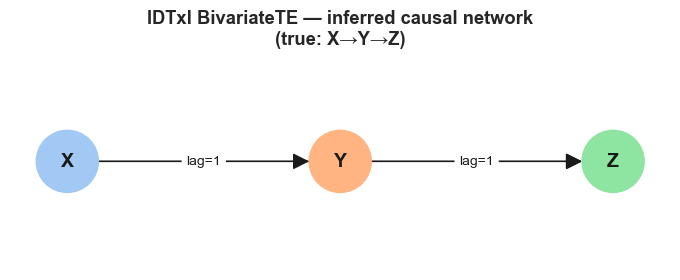

In [11]:
G = nx.DiGraph()
G.add_nodes_from(process_labels)
for s, t, lag, pval in edges:
    if not G.has_edge(s, t):
        G.add_edge(s, t, lag=lag, pval=pval)

pos = {'X': (0, 0), 'Y': (1, 0), 'Z': (2, 0)}
edge_labels = {(u, v): f"lag={d['lag']}" for u, v, d in G.edges(data=True)}

fig, ax = plt.subplots(figsize=(7, 3))
nx.draw_networkx(G, pos=pos, ax=ax, node_size=2000,
                 node_color=sns.color_palette('pastel')[:3],
                 arrows=True, arrowsize=25, font_size=14, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels,
                             ax=ax, font_size=10)
ax.set_title('IDTxl BivariateTE — inferred causal network\n(true: X→Y→Z)',
             fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Real Data — UCI Wine Dataset

We treat the top-4 features as a pseudo-multivariate time series and infer a network.
This is illustrative — Wine samples are not sequential, so any detected links reflect
co-variation rather than temporal causality.

Wine features are **continuous real values**, so we switch to `JidtKraskovCMI`,
the appropriate k-nearest-neighbour estimator for continuous data.
We also normalise the data so that all features live on a comparable scale.

In [12]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
feature_names  = list(wine.feature_names)

mi_scores = mutual_info_classif(X_wine, y_wine, random_state=SEED)
order = np.argsort(mi_scores)[::-1]
top4  = [feature_names[i] for i in order[:4]]
X_top4 = X_wine[:, order[:4]].T.astype(float)   # (4, 178)
print("Top-4 features:", top4)

wine_data = IDTxlData(X_top4, dim_order='ps', normalise=True)
print(f"IDTxl Data: {wine_data.n_processes} processes × {wine_data.n_samples} samples")

Top-4 features: ['flavanoids', 'proline', 'color_intensity', 'od280/od315_of_diluted_wines']
Adding data with properties: 4 processes, 178 samples, 1 replications
overwriting existing data
IDTxl Data: 4 processes × 178 samples


> **Note**: this cell takes ~60–90 s because it runs permutation tests.

In [13]:
settings_wine = {
    'cmi_estimator':  'JidtKraskovCMI',
    'max_lag_sources': 2,
    'min_lag_sources': 1,
    'max_lag_target':  1,
    'n_perm_max_stat': 100,
    'n_perm_min_stat': 100,
    'n_perm_omnibus':  100,
    'alpha_max_stat':  0.05,
    'alpha_min_stat':  0.05,
    'alpha_omnibus':   0.05,
}

print("Running BivariateTE on Wine data …")
results_wine = BivariateTE().analyse_network(settings=settings_wine, data=wine_data)
print("Done.")

edges_wine = []
for tgt in range(4):
    res     = results_wine.get_single_target(tgt, fdr=False)
    sources = res.get('selected_vars_sources') or []
    pvals   = res.get('selected_sources_pval')
    if pvals is None: pvals = []
    for (src, lag), pval in zip(sources, pvals):
        edges_wine.append((top4[src][:10], top4[tgt][:10], lag, float(pval)))

print("\nSignificant edges in Wine network:")
for s, t, lag, pval in sorted(edges_wine):
    print(f"  {s} → {t}   lag={lag}  p={pval:.4f}")
if not edges_wine:
    print("  (None found at α=0.05 — the wine samples have no true temporal ordering)")

Running BivariateTE on Wine data …

####### analysing target with index 0 from list [0, 1, 2, 3]

Target: 0 - testing sources [1, 2, 3]

---------------------------- (1) include target candidates
candidate set: [(0, 1)]
testing candidate: (0, 1) 
maximum statistic, n_perm: 100

---------------------------- (2) include source candidates
candidate set current source: [(1, 1), (1, 2)]
testing candidate: (1, 1) maximum statistic, n_perm: 100
 -- not significant
candidate set current source: [(2, 1), (2, 2)]
testing candidate: (2, 2) maximum statistic, n_perm: 100
testing candidate: (2, 1) maximum statistic, n_perm: 100
 -- not significant
candidate set current source: [(3, 1), (3, 2)]
testing candidate: (3, 2) maximum statistic, n_perm: 100
 -- not significant

---------------------------- (3) prune candidates
selected vars sources [(2, 0)]
selected candidates current source: [(2, 2)]
 -- significant

---------------------------- (4) final statistics
selected variables: [(0, 1), (2, 2)]
om